# Air Quality Data Analysis
Exploring the relationships between PM2.5, PM10, Humidity, CO, Temperature, and AQI with individual plots per cell.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load and prepare data
df = pd.read_csv('output/integrated_air_quality_data.csv')
df['ts'] = pd.to_datetime(df['ts'])
df = df.sort_values('ts')

sns.set_theme(style="whitegrid")

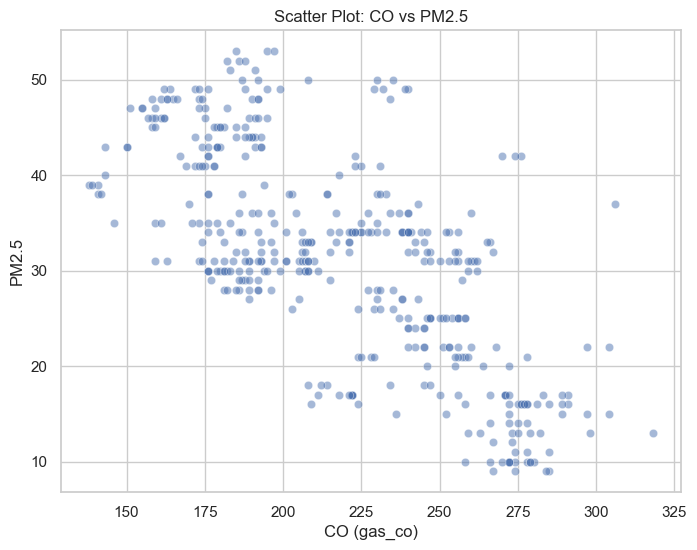

In [2]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='gas_co', y='pm25', alpha=0.5)
plt.title('Scatter Plot: CO vs PM2.5')
plt.xlabel('CO (gas_co)')
plt.ylabel('PM2.5')
plt.show()

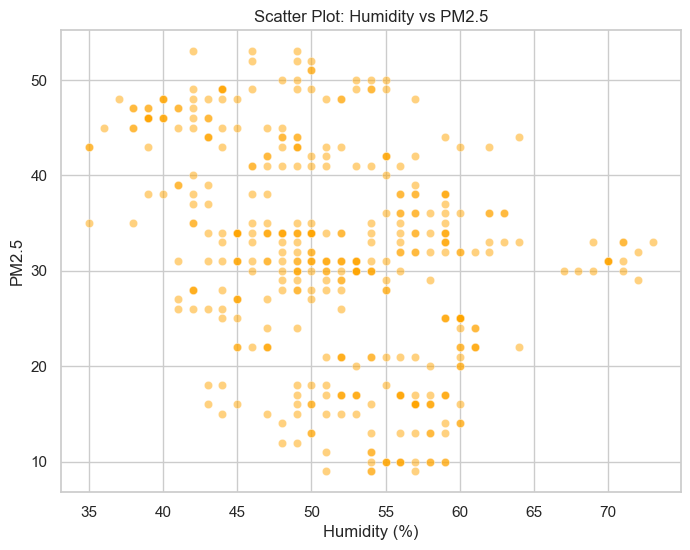

In [3]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='humidity', y='pm25', alpha=0.5, color='orange')
plt.title('Scatter Plot: Humidity vs PM2.5')
plt.xlabel('Humidity (%)')
plt.ylabel('PM2.5')
plt.show()

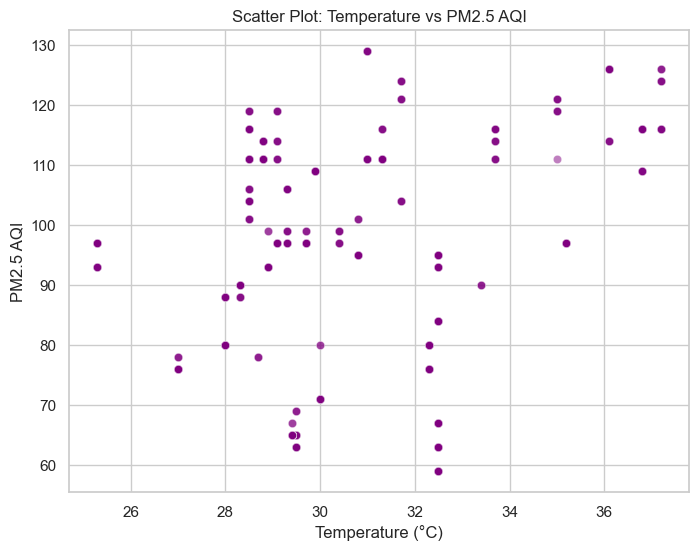

In [4]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='temp_tmd', y='pm25_aqi', alpha=0.5, color='purple')
plt.title('Scatter Plot: Temperature vs PM2.5 AQI')
plt.xlabel('Temperature (\u00b0C)')
plt.ylabel('PM2.5 AQI')
plt.show()

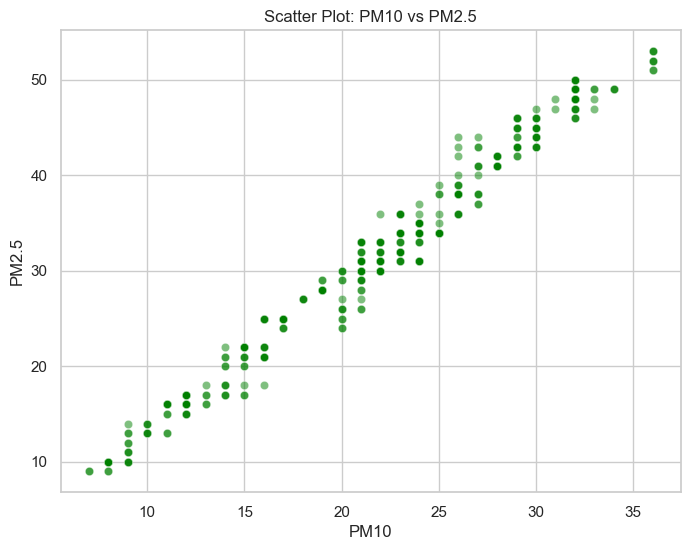

In [5]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='pm10', y='pm25', alpha=0.5, color='green')
plt.title('Scatter Plot: PM10 vs PM2.5')
plt.xlabel('PM10')
plt.ylabel('PM2.5')
plt.show()

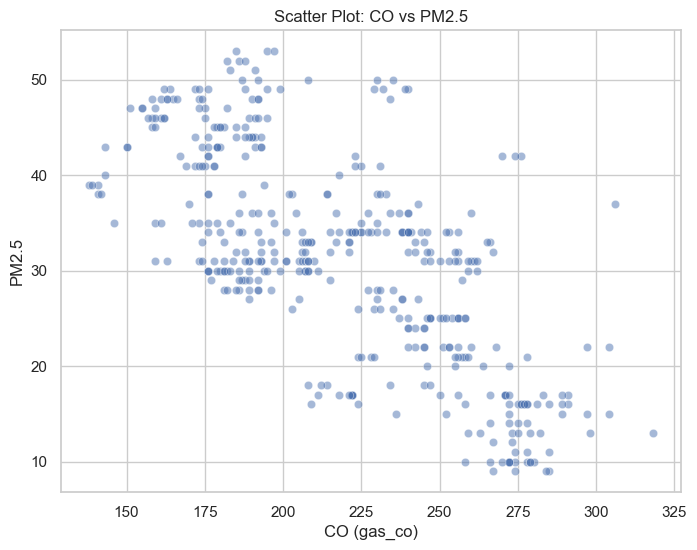

Saved image to: ..\frontend\public\sensor-graph-co-pm25.png


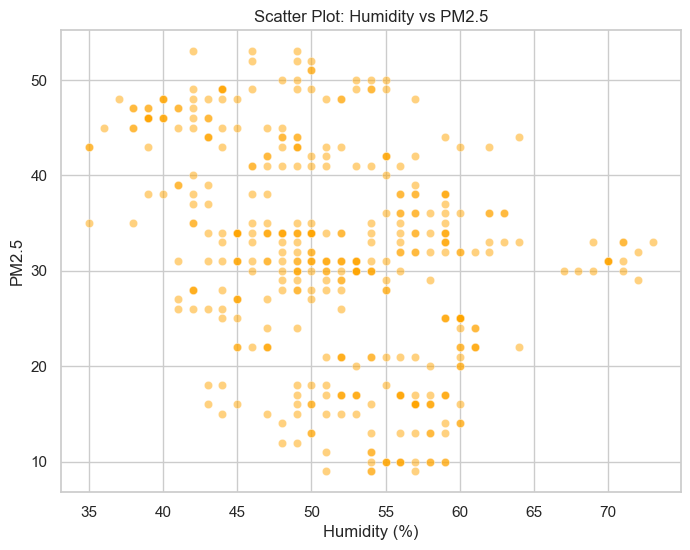

Saved image to: ..\frontend\public\sensor-graph-humidity-pm25.png


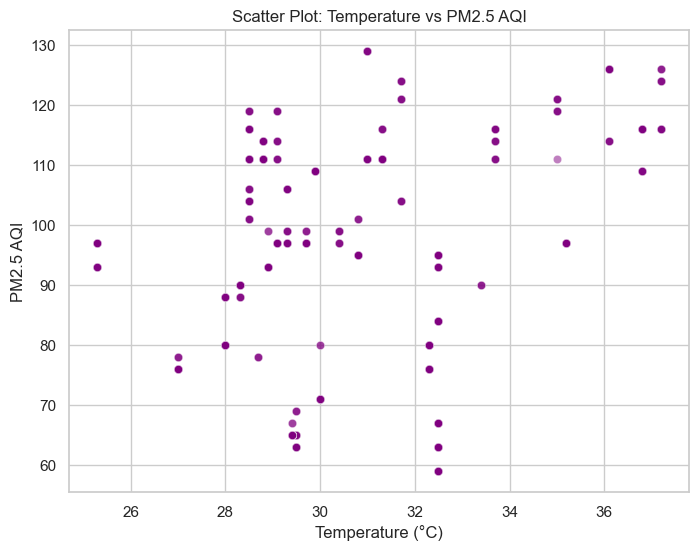

Saved image to: ..\frontend\public\sensor-graph-temp-aqi.png


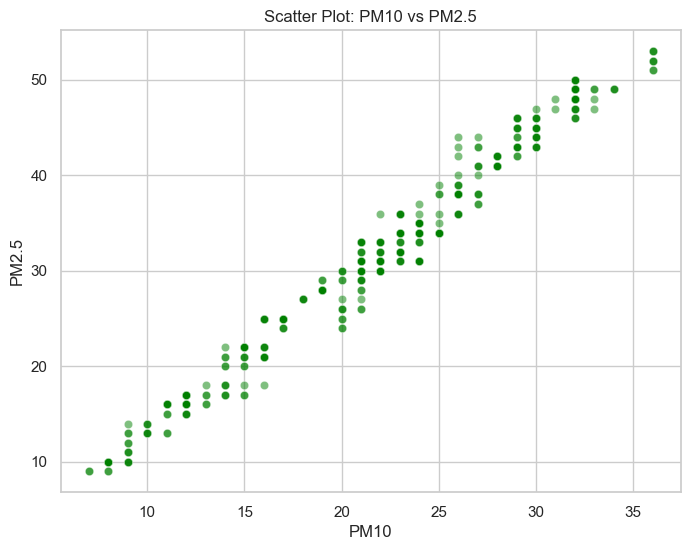

Saved image to: ..\frontend\public\sensor-graph-pm10-pm25.png


In [6]:
import os

# Save each scatter plot as a separate image for the website
output_dir = os.path.join("..", "frontend", "public")
os.makedirs(output_dir, exist_ok=True)

plot_specs = [
    ("gas_co", "pm25", "CO (gas_co)", "PM2.5", "Scatter Plot: CO vs PM2.5", None, "sensor-graph-co-pm25.png"),
    ("humidity", "pm25", "Humidity (%)", "PM2.5", "Scatter Plot: Humidity vs PM2.5", "orange", "sensor-graph-humidity-pm25.png"),
    ("temp_tmd", "pm25_aqi", "Temperature (°C)", "PM2.5 AQI", "Scatter Plot: Temperature vs PM2.5 AQI", "purple", "sensor-graph-temp-aqi.png"),
    ("pm10", "pm25", "PM10", "PM2.5", "Scatter Plot: PM10 vs PM2.5", "green", "sensor-graph-pm10-pm25.png"),
]

for x_col, y_col, x_label, y_label, title, color, filename in plot_specs:
    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=df, x=x_col, y=y_col, alpha=0.5, color=color)
    plt.title(title)
    plt.xlabel(x_label)
    plt.ylabel(y_label)

    file_path = os.path.join(output_dir, filename)
    plt.savefig(file_path, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"Saved image to: {file_path}")

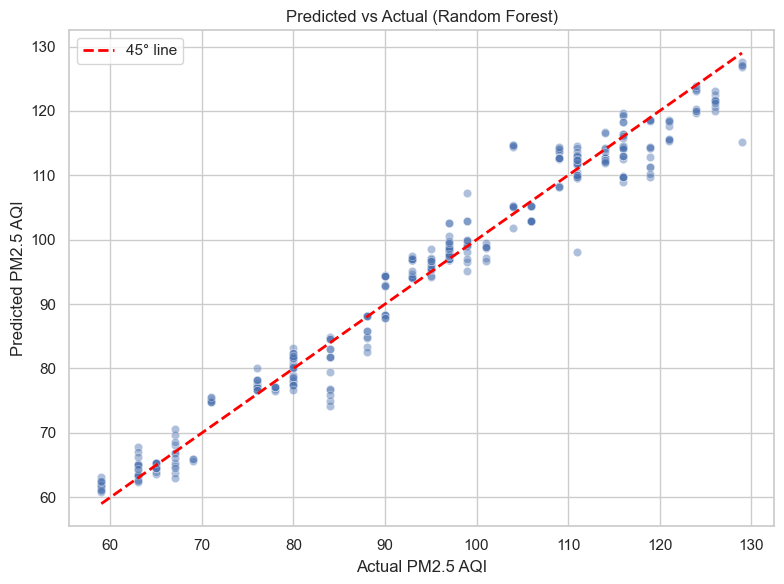

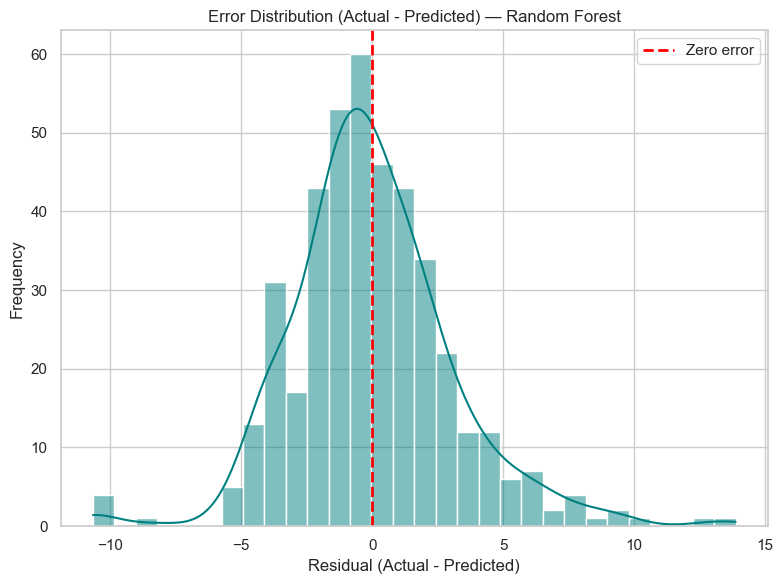

Saved -> ..\backend\static\residual_predicted_vs_actual.png
Saved -> ..\backend\static\residual_error_distribution.png


In [7]:
from pathlib import Path
import joblib

# Residual Analysis for model transparency (Random Forest)
feature_cols = [
    'temp', 'humidity', 'gas_co',
    'temp_tmd', 'humidity_tmd', 'rainfall_tmd',
    'place_enc', 'pm25', 'pm10',
]
target_col = 'pm25_aqi'

eval_df = df.copy()
eval_df['place_enc'] = eval_df['place'].astype(str).str.lower().map({'inside': 0, 'outdoor': 1})
eval_df = eval_df[feature_cols + [target_col]].dropna()

X_eval = eval_df[feature_cols]
y_actual = eval_df[target_col]

rf_model = joblib.load('../backend/models/rf_model.pkl')
y_pred = rf_model.predict(X_eval)
residuals = y_actual - y_pred

static_dir = Path('../backend/static')
static_dir.mkdir(parents=True, exist_ok=True)

# 1) Predicted vs Actual with 45-degree line
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_actual, y=y_pred, alpha=0.45)
min_val = min(y_actual.min(), y_pred.min())
max_val = max(y_actual.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='45° line')
plt.title('Predicted vs Actual (Random Forest)')
plt.xlabel('Actual PM2.5 AQI')
plt.ylabel('Predicted PM2.5 AQI')
plt.legend()
plt.tight_layout()
pred_vs_actual_path = static_dir / 'residual_predicted_vs_actual.png'
plt.savefig(pred_vs_actual_path, dpi=200, bbox_inches='tight')
plt.show()

# 2) Error distribution (Actual - Predicted)
plt.figure(figsize=(8, 6))
sns.histplot(residuals, bins=30, kde=True, color='teal')
plt.axvline(0, color='red', linestyle='--', linewidth=2, label='Zero error')
plt.title('Error Distribution (Actual - Predicted) — Random Forest')
plt.xlabel('Residual (Actual - Predicted)')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
error_dist_path = static_dir / 'residual_error_distribution.png'
plt.savefig(error_dist_path, dpi=200, bbox_inches='tight')
plt.show()

print(f'Saved -> {pred_vs_actual_path}')
print(f'Saved -> {error_dist_path}')

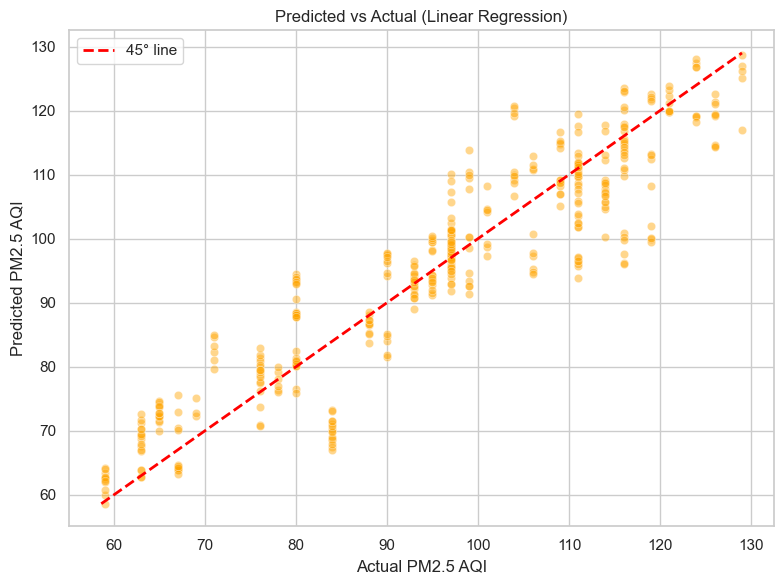

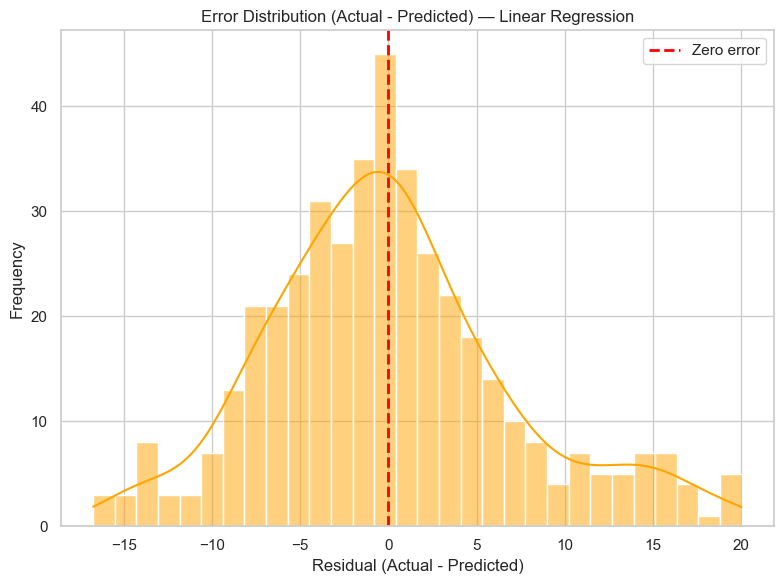

Saved -> ..\backend\static\residual_predicted_vs_actual_mlr.png
Saved -> ..\backend\static\residual_error_distribution_mlr.png


In [8]:
from pathlib import Path
import joblib

# Residual Analysis for Linear Regression
feature_cols = [
    'temp', 'humidity', 'gas_co',
    'temp_tmd', 'humidity_tmd', 'rainfall_tmd',
    'place_enc', 'pm25', 'pm10',
]
target_col = 'pm25_aqi'

eval_df = df.copy()
eval_df['place_enc'] = eval_df['place'].astype(str).str.lower().map({'inside': 0, 'outdoor': 1})
eval_df = eval_df[feature_cols + [target_col]].dropna()

X_eval = eval_df[feature_cols]
y_actual = eval_df[target_col]

mlr_model = joblib.load('../backend/models/mlr_model.pkl')
y_pred_mlr = mlr_model.predict(X_eval)
residuals_mlr = y_actual - y_pred_mlr

static_dir = Path('../backend/static')
static_dir.mkdir(parents=True, exist_ok=True)

# 1) Predicted vs Actual
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_actual, y=y_pred_mlr, alpha=0.45, color='orange')
min_val = min(y_actual.min(), y_pred_mlr.min())
max_val = max(y_actual.max(), y_pred_mlr.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='45° line')
plt.title('Predicted vs Actual (Linear Regression)')
plt.xlabel('Actual PM2.5 AQI')
plt.ylabel('Predicted PM2.5 AQI')
plt.legend()
plt.tight_layout()
pred_vs_actual_mlr_path = static_dir / 'residual_predicted_vs_actual_mlr.png'
plt.savefig(pred_vs_actual_mlr_path, dpi=200, bbox_inches='tight')
plt.show()

# 2) Error distribution
plt.figure(figsize=(8, 6))
sns.histplot(residuals_mlr, bins=30, kde=True, color='orange')
plt.axvline(0, color='red', linestyle='--', linewidth=2, label='Zero error')
plt.title('Error Distribution (Actual - Predicted) — Linear Regression')
plt.xlabel('Residual (Actual - Predicted)')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
error_dist_mlr_path = static_dir / 'residual_error_distribution_mlr.png'
plt.savefig(error_dist_mlr_path, dpi=200, bbox_inches='tight')
plt.show()

print(f'Saved -> {pred_vs_actual_mlr_path}')
print(f'Saved -> {error_dist_mlr_path}')
